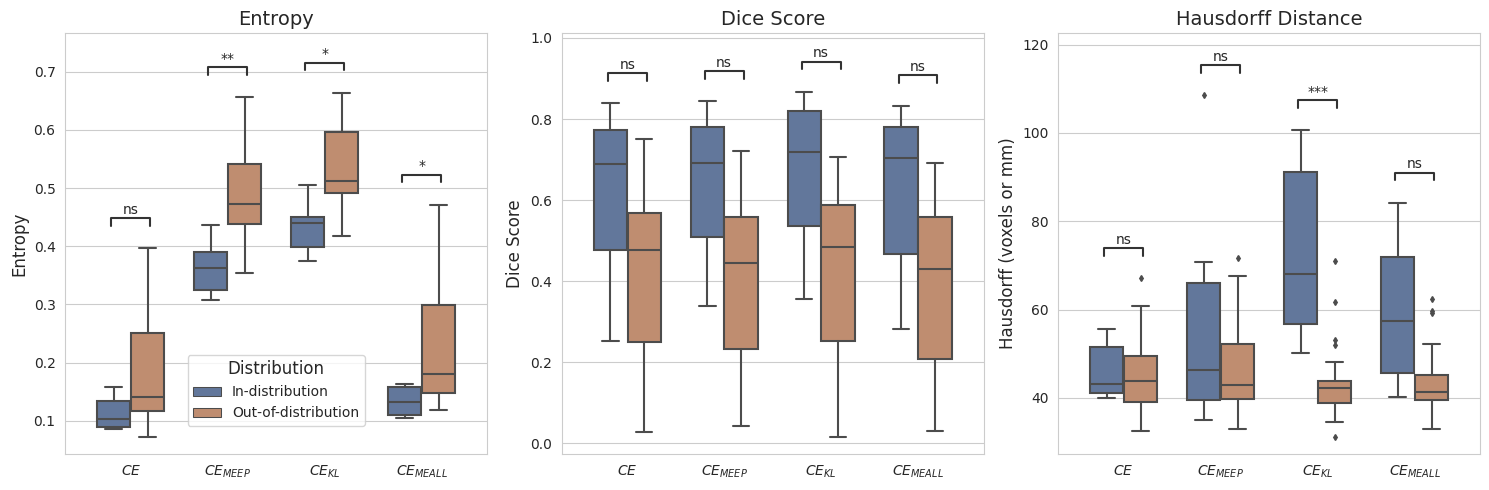

In [4]:
import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

from src.datamodules import WMHDataModule
from notebooks.utils.metrics_utils import * # Imports plt, sns, pd, np
sns.set_style("whitegrid")

from scipy.stats import pearsonr, spearmanr # Added spearmanr

# Font sizes (inspired by fig2 for consistency)
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

# Apply global font settings (adapted from fig2, theme-neutral)
plt.rc('font', size=SMALL_SIZE, family='sans-serif')
plt.rc('axes', titlesize=MEDIUM_SIZE)       # Default title size for axes
plt.rc('xtick', labelsize=SMALL_SIZE)      # Default X tick label size
plt.rc('ytick', labelsize=SMALL_SIZE)      # Default Y tick label size
plt.rc('legend', fontsize=SMALL_SIZE)      # Default legend font size
plt.rc('figure', titlesize=BIGGER_SIZE)    # Default figure title size (e.g., for suptitle)


data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}  # Group for plot
rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

for key, val in group_test.items():  # Group test datasets if needed
    test_splits[key] = []
    for center in val:
        test_splits[key] += test_splits[center]
        del test_splits[center]
        # Remove center from centers_test
        centers_test.remove(center)
    centers_test.append(key)
    
plot_data = {
'centers_train': centers_train,
'runs_to_compare': runs_to_compare,
'centers_test': centers_test,
'test_splits': test_splits,
'losses': losses,
}

subjs = [pths for pths in test_splits.values()]

import os
import numpy as np
import pandas as pd
import nibabel as nib
from scipy.spatial.distance import directed_hausdorff

import numpy as np
from scipy.spatial.distance import directed_hausdorff

def calculate_hausdorff(gt_mask, pred_mask, voxel_spacing=None):
    """
    gt_mask, pred_mask: numpy arrays (0/1)
    voxel_spacing: tuple/list de longitudes de voxel (una por dimensión) o None
    """
    coords_gt   = np.argwhere(gt_mask   > 0)
    coords_pred = np.argwhere(pred_mask > 0)

    # caso ambos vacíos → distancia 0
    if coords_gt.size == 0 and coords_pred.size == 0:
        return 0.0

    # caso uno vacío → diagonal máxima del volumen
    if coords_gt.size == 0 or coords_pred.size == 0:
        # dim en voxels
        dims = np.array(gt_mask.shape)
        # si hay spacing, convierto a unidades físicas
        if voxel_spacing is not None and len(voxel_spacing) == gt_mask.ndim:
            dims = dims * np.array(voxel_spacing)
        # diagonal
        # print() # Removed print statement
        return np.linalg.norm(dims)

    # caso habitual: Hausdorff bidireccional
    if voxel_spacing is not None and len(voxel_spacing) == gt_mask.ndim:
        coords_gt   = coords_gt   * np.array(voxel_spacing)
        coords_pred = coords_pred * np.array(voxel_spacing)

    hd1 = directed_hausdorff(coords_gt,   coords_pred)[0]
    hd2 = directed_hausdorff(coords_pred, coords_gt)[0]
    return max(hd1, hd2)


def dice_score(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    s     = np.sum(y_true) + np.sum(y_pred)
    return 1.0 if s==0 else 2.0*inter/s

def compute_all_metrics(plot_data,
                        entropy_m_type='softmax_pos_class',
                        use_header_spacing=True):
    """
    Returns DataFrame with columns:
      ['Center','Loss','Distribution','Entropy','Dice Score','Hausdorff Distance', 'Case']
    """
    centers_train, runs_to_compare, centers_test, splits, losses = plot_data.values()
    rename = {"UtAmSi":"In-distribution","UMCL":"Out-of-distribution"}

    def get_gt_paths(lst):
        # Assumes splits dictionary structure is {'center': [[t1, flair, gt], ...]}
        # Need to adjust if splits structure is different, e.g., plot_data['test_splits']
        return [os.path.dirname(p[2]) for p in lst]

    def get_brain_mask(base):
        pre = os.path.join(base,'pre')
        for nm in ('brain_mask.nii.gz','brain.nii.gz'):
            p = os.path.join(pre,nm)
            if os.path.exists(p): return p
        return None

    records = []
    # Use the correct key for splits from plot_data
    splits_dict = plot_data.get('test_splits', splits) # Use 'test_splits' if available

    for tr in centers_train:
        for loss in losses:
            run = runs_to_compare.get(f'{loss} {tr}')
            if not run: continue
            for ts in centers_test:
                dist = rename.get(ts, ts)
                # Ensure we are using the correct split data for the test center 'ts'
                if ts not in splits_dict: continue # Skip if test center not in splits
                for subj in get_gt_paths(splits_dict[ts]):
                    try:
                        gt_path = os.path.join(subj, f'gt_wmh_{run}.nii.gz')
                        pred_path = os.path.join(subj, f'pred_wmh_softmax_{run}.nii.gz')

                        # Check if files exist before loading
                        if not os.path.exists(gt_path) or not os.path.exists(pred_path):
                            # print(f"Warning: Missing files for subject {subj}, run {run}. Skipping.")
                            continue

                        gt_img   = nib.load(gt_path)
                        pred_img = nib.load(pred_path)
                        gt = gt_img.get_fdata()
                        pr = pred_img.get_fdata()
                        # Ensure prediction has probability for positive class if it's multi-channel
                        if pr.ndim > gt.ndim and pr.shape[-1] > 1:
                           pr = pr[...,1]
                        elif pr.ndim > gt.ndim and pr.shape[-1] == 1:
                           pr = pr[...,0]


                        if use_header_spacing:
                            vox = gt_img.header.get_zooms()[: gt.ndim]
                        else:
                            vox = None

                        # entropy
                        flat = pr.flatten()
                        if   entropy_m_type=='softmax_pos_class':
                            sel = flat[flat>=0.5]
                        elif entropy_m_type=='gt':
                            sel = flat[gt.flatten()==1]
                        else: # brain mask based
                            bm_path = get_brain_mask(subj)
                            if bm_path and os.path.exists(bm_path):
                                bm = nib.load(bm_path).get_fdata()
                                # Ensure brain mask has same shape as gt/pr
                                if bm.shape == gt.shape:
                                     sel = flat[bm.flatten()==1]
                                else:
                                     # print(f"Warning: Brain mask shape mismatch for {subj}. Using empty selection.")
                                     sel = np.empty(0)
                            else:
                                # print(f"Warning: No brain mask found for {subj}. Using empty selection.")
                                sel = np.empty(0)

                        if sel.size>0:
                            p  = np.clip(sel,1e-10,1-1e-10)
                            ev = -p*np.log(p)-(1-p)*np.log(1-p)
                            ent = ev.mean()
                        else:
                            ent = 0.0 # Assign 0 entropy if selection is empty

                        # dice
                        bin_pr = (pr>=0.5).astype(np.int8)
                        dsc    = dice_score(gt.astype(np.int8), bin_pr)

                        # classify the case for Hausdorff
                        coords_gt   = np.argwhere(gt     > 0)
                        coords_pred = np.argwhere(bin_pr > 0)

                        if coords_gt.size==0 and coords_pred.size==0:
                            case = 'no_gt_no_pred'
                            hd   = 0.0
                        elif coords_gt.size==0 or coords_pred.size==0:
                            case = 'one_empty'
                            # compute diagonal
                            dims = np.array(gt.shape)
                            if vox is not None: 
                                dims = dims * np.array(vox)
                            hd = np.linalg.norm(dims)
                        else:
                            case = 'normal'
                            hd = calculate_hausdorff(gt, bin_pr, voxel_spacing=vox)


                        records.append({
                          'Center':             tr,
                          'Loss':               loss,
                          'Distribution':       dist,
                          'Entropy':            ent,
                          'Dice Score':         dsc,
                          'Hausdorff Distance': hd,
                          'Case':               case # Add the case label
                        })
                    except FileNotFoundError:
                         # print(f"Warning: File not found during processing for subject {subj}, run {run}. Skipping.")
                         pass # Or log the error more formally
                    except Exception as e:
                         # print(f"Error processing subject {subj}, run {run}: {e}")
                         pass # Catch other potential errors like loading issues

    return pd.DataFrame(records)

df = compute_all_metrics(plot_data)

import matplotlib.pyplot as plt
import seaborn as sns
from statannot import add_stat_annotation

def plot_metrics_boxes(df,
                       center,
                       metrics=('Entropy','Dice Score','Hausdorff Distance'),
                       hue_order=('In-distribution','Out-of-distribution')):
    """
    Filters by `center` before plotting so stats are per-training-center.
    """
    # 1) subset to the chosen training center
    df = df[df['Center']==center]

    # 2) drop NaN/inf
    df = df.dropna(subset=metrics)
    df = df[~np.isinf(df['Hausdorff Distance'])]

    # 3) melt
    df_melt = df.melt(id_vars=['Loss','Distribution'],
                      value_vars=metrics,
                      var_name='Metric', value_name='Value')

    # 4) plot
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=False) # Changed figsize from (6.2*n, 6) to (5*n, 5)
    # sns.set_context("talk", font_scale=1) # Removed for consistency
    sns.set_style("whitegrid")

    # Define a custom darker palette
    # Original seaborn default-like: ['#1f77b4', '#ff7f0e']
    # Previous darker: ['#005082', '#c45400']
    custom_palette = ['#5975a4', '#cc8963'] # Adjusted: less dark blue and orange

    for ax, metric in zip(axes, metrics):
        sub = df_melt[df_melt['Metric']==metric]
        sns.boxplot(x='Loss', y='Value', hue='Distribution',
                    hue_order=hue_order, data=sub, ax=ax,
                    width=0.7, fliersize=3, palette=custom_palette) # Added palette

        # Mann-Whitney per-loss
        pairs = [
            ((L, hue_order[0]), (L, hue_order[1]))
            for L in sub['Loss'].unique()
            if ((sub['Loss']==L)&(sub['Distribution']==hue_order[0])).any()
            and ((sub['Loss']==L)&(sub['Distribution']==hue_order[1])).any()
        ]
        if pairs:
            add_stat_annotation(ax, data=sub, x='Loss', y='Value', hue='Distribution',
                                box_pairs=pairs, test='Mann-Whitney',
                                text_format='star', loc='inside', verbose=0)

        # LaTeX x-labels
        xt = []
        for lbl in ax.get_xticklabels():
            txt = lbl.get_text()
            if '_' in txt:
                name, sub_ = txt.split('_',1)
                xt.append(rf'${name}_{{{sub_}}}$')
            else:
                xt.append(rf'${txt}$')
        ax.set_xticklabels(xt, fontsize=SMALL_SIZE) # Changed from 14 to SMALL_SIZE

        ax.set_title(metric, fontsize=BIGGER_SIZE) # Changed from 18 to BIGGER_SIZE
        ax.set_xlabel('', fontsize=MEDIUM_SIZE) # Changed from 16 to MEDIUM_SIZE
        ax.set_ylabel(metric if metric!='Hausdorff Distance'
                      else 'Hausdorff (voxels or mm)',
                      fontsize=MEDIUM_SIZE) # Changed from 16 to MEDIUM_SIZE
        ax.tick_params(axis='both', labelsize=SMALL_SIZE) # Changed from 14 to SMALL_SIZE
        ax.legend_.remove()

    # stacked legend inside first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, title='Distribution',
                   loc='lower center', bbox_to_anchor=(0.5,0.05),
                   ncol=1, frameon=True, fontsize=SMALL_SIZE, title_fontsize=MEDIUM_SIZE) # Changed to SMALL_SIZE and MEDIUM_SIZE

    plt.tight_layout()
    
    # Save the figure
    output_dir = 'notebooks/main/figs/pdfs/'
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, 'Figure5.pdf')
    plt.savefig(file_path, format='pdf', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()
    
plot_metrics_boxes(df, center='UtAmSi')